# Pre-Challenge 2b — Analisis Potensi Investasi Deposito Nasabah

## Problem Statement
Bank ingin meningkatkan **Customer Lifetime Value (CLV)** dengan mendorong nasabah existing untuk berinvestasi pada produk simpanan jangka panjang. Analisis data diperlukan untuk mengidentifikasi nasabah existing dengan potensi investasi jangka panjang tertinggi.

## Challenge
1. Lakukan EDA untuk melihat hubungan antara profil nasabah dan keputusan berlangganan deposito.
2. Analisis pola berdasarkan usia, saldo, dan status pinjaman.
3. Simpulkan tipe nasabah yang paling potensial untuk ditargetkan oleh relationship manager.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold'
})

## 1. Load & Inspeksi Data

In [16]:
df = pd.read_csv('idx_ds-challenge_2b.csv')
print(f"Shape: {df.shape}")
print(f"\nKolom:\n{list(df.columns)}")
df.head()

Shape: (30, 15)

Kolom:
['customer_id', 'age', 'job', 'marital', 'education', 'years_as_customer', 'avg_monthly_balance', 'total_products_owned', 'housing_loan', 'personal_loan', 'credit_card', 'investment_experience', 'contact_channel', 'relationship_manager_contact', 'subscription']


,customer_id,age,job,marital,education,years_as_customer,avg_monthly_balance,total_products_owned,housing_loan,personal_loan,credit_card,investment_experience,contact_channel,relationship_manager_contact,subscription
0,1,46,management,married,tertiary,12,18000000,4,no,no,yes,yes,cellular,yes,yes
1,2,34,technician,married,secondary,6,5200000,2,yes,no,yes,no,cellular,no,no
2,3,58,retired,married,primary,20,32000000,5,no,no,no,yes,telephone,yes,yes
3,4,29,admin,single,secondary,3,2800000,1,no,no,no,no,cellular,no,no
4,5,42,self-employed,married,tertiary,10,15000000,3,yes,yes,yes,yes,cellular,yes,yes


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   customer_id                   30 non-null     int64
 1   age                           30 non-null     int64
 2   job                           30 non-null     str  
 3   marital                       30 non-null     str  
 4   education                     30 non-null     str  
 5   years_as_customer             30 non-null     int64
 6   avg_monthly_balance           30 non-null     int64
 7   total_products_owned          30 non-null     int64
 8   housing_loan                  30 non-null     str  
 9   personal_loan                 30 non-null     str  
 10  credit_card                   30 non-null     str  
 11  investment_experience         30 non-null     str  
 12  contact_channel               30 non-null     str  
 13  relationship_manager_contact  30 non-null     st

In [18]:
# Cek missing values
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing Values:
customer_id                     0
age                             0
job                             0
marital                         0
education                       0
years_as_customer               0
avg_monthly_balance             0
total_products_owned            0
housing_loan                    0
personal_loan                   0
credit_card                     0
investment_experience           0
contact_channel                 0
relationship_manager_contact    0
subscription                    0
dtype: int64

Total missing: 0


In [19]:
# Statistik deskriptif numerik
df.describe()

,customer_id,age,years_as_customer,avg_monthly_balance,total_products_owned
count,30.000000,30.000000,30.000000,3.000000e+01,30.000000
mean,15.500000,42.200000,10.333333,1.454333e+07,2.933333
std,8.803408,9.970301,6.155084,1.130385e+07,1.436791
min,1.000000,27.000000,2.000000,1.300000e+06,1.000000
25%,8.250000,34.250000,6.000000,4.900000e+06,2.000000
50%,15.500000,40.500000,9.000000,1.120000e+07,2.500000
75%,22.750000,48.750000,14.000000,2.212500e+07,4.000000
max,30.000000,61.000000,23.000000,3.700000e+07,5.000000


In [20]:
# Statistik deskriptif kategorikal
df.describe(include='object')

,job,marital,education,housing_loan,personal_loan,credit_card,investment_experience,contact_channel,relationship_manager_contact,subscription
count,30,30,30,30,30,30,30,30,30,30
unique,8,3,3,2,2,2,2,2,2,2
top,management,married,secondary,no,no,yes,yes,cellular,yes,yes
freq,4,21,15,21,29,19,15,24,15,15


In [21]:
# Distribusi target variable
print("Distribusi Subscription:")
print(df['subscription'].value_counts())
print(f"\nProporsi: {df['subscription'].value_counts(normalize=True).round(3).to_dict()}")

Distribusi Subscription:
subscription
yes    15
no     15
Name: count, dtype: int64

Proporsi: {'yes': 0.5, 'no': 0.5}


## 2. Exploratory Data Analysis

### 2.1 Hubungan Profil Nasabah dengan Keputusan Deposito

#### 2.1.1 Distribusi Usia berdasarkan Subscription

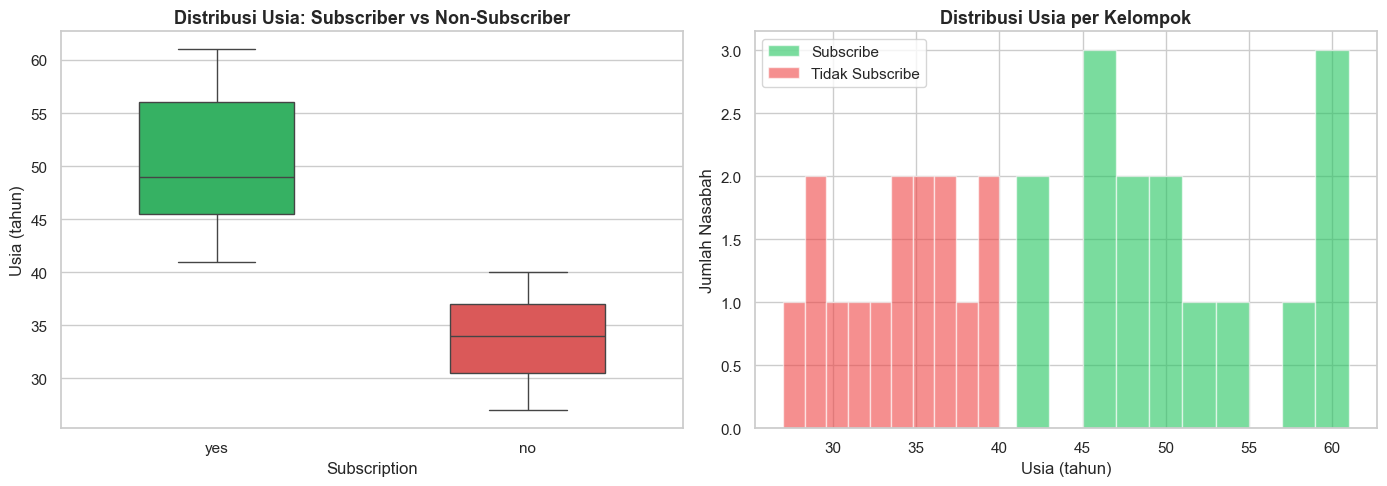

Statistik Usia per Kelompok:
              mean  median  min  max
subscription                        
no            33.9    34.0   27   40
yes           50.5    49.0   41   61


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(data=df, x='subscription', y='age', ax=axes[0],
            palette={'yes': '#22c55e', 'no': '#ef4444'}, width=0.5)
axes[0].set_title('Distribusi Usia: Subscriber vs Non-Subscriber')
axes[0].set_xlabel('Subscription')
axes[0].set_ylabel('Usia (tahun)')

# Histogram overlay
for sub, color, label in [('yes', '#22c55e', 'Subscribe'), ('no', '#ef4444', 'Tidak Subscribe')]:
    subset = df[df['subscription'] == sub]['age']
    axes[1].hist(subset, bins=10, alpha=0.6, color=color, label=label, edgecolor='white')
axes[1].set_title('Distribusi Usia per Kelompok')
axes[1].set_xlabel('Usia (tahun)')
axes[1].set_ylabel('Jumlah Nasabah')
axes[1].legend()

plt.tight_layout()
plt.show()

# Stats
print("Statistik Usia per Kelompok:")
print(df.groupby('subscription')['age'].agg(['mean', 'median', 'min', 'max']).round(1))

#### 2.1.2 Distribusi Saldo Bulanan Rata-rata

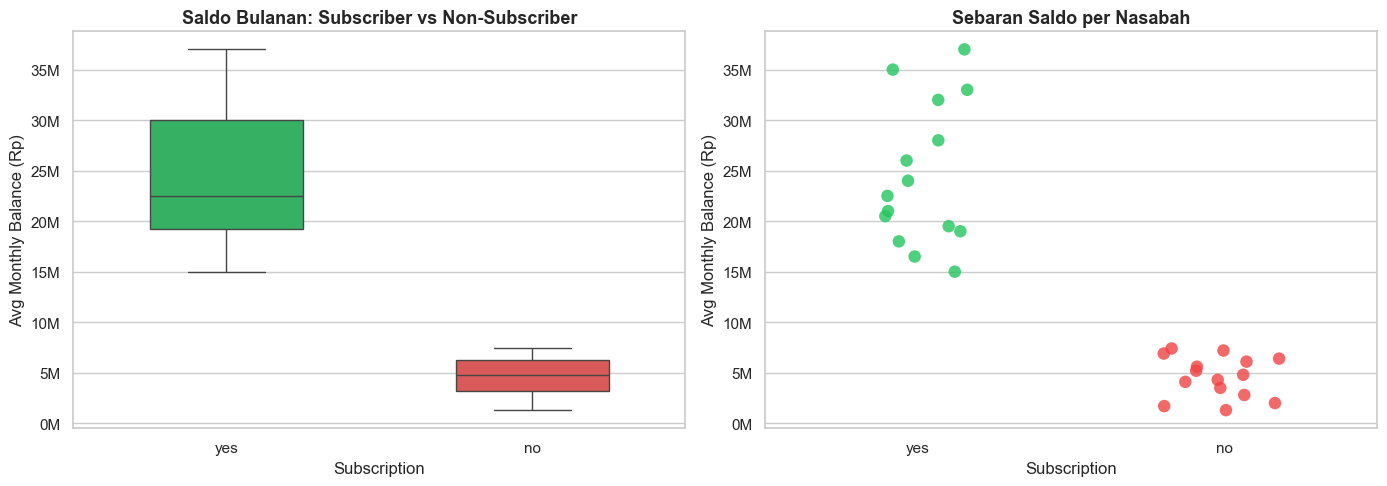

Statistik Saldo per Kelompok:
                  mean    median       min       max
subscription                                        
no             Rp 4.6M   Rp 4.8M   Rp 1.3M   Rp 7.4M
yes           Rp 24.5M  Rp 22.5M  Rp 15.0M  Rp 37.0M


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot saldo
sns.boxplot(data=df, x='subscription', y='avg_monthly_balance', ax=axes[0],
            palette={'yes': '#22c55e', 'no': '#ef4444'}, width=0.5)
axes[0].set_title('Saldo Bulanan: Subscriber vs Non-Subscriber')
axes[0].set_xlabel('Subscription')
axes[0].set_ylabel('Avg Monthly Balance (Rp)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# Strip plot
sns.stripplot(data=df, x='subscription', y='avg_monthly_balance', ax=axes[1],
              palette={'yes': '#22c55e', 'no': '#ef4444'}, size=9, jitter=0.2, alpha=0.8)
axes[1].set_title('Sebaran Saldo per Nasabah')
axes[1].set_xlabel('Subscription')
axes[1].set_ylabel('Avg Monthly Balance (Rp)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

plt.tight_layout()
plt.show()

print("Statistik Saldo per Kelompok:")
stats = df.groupby('subscription')['avg_monthly_balance'].agg(['mean', 'median', 'min', 'max'])
print(stats.map(lambda x: f"Rp {x/1e6:.1f}M"))

### 2.2 Analisis Pola: Usia, Saldo, dan Status Pinjaman

#### 2.2.1 Housing Loan vs Subscription

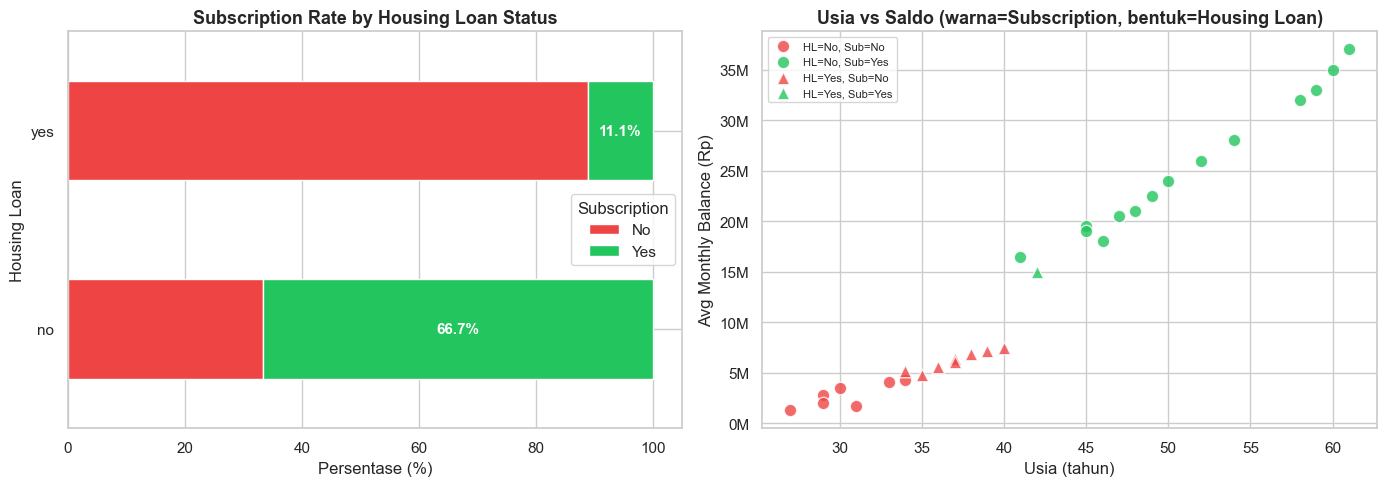


Crosstab Housing Loan vs Subscription:
subscription  no  yes  All
housing_loan              
no             7   14   21
yes            8    1    9
All           15   15   30

Subscription rate TANPA housing loan: 66.7%
Subscription rate DENGAN housing loan: 11.1%


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Crosstab housing loan
ct_housing = pd.crosstab(df['housing_loan'], df['subscription'])
ct_housing_pct = pd.crosstab(df['housing_loan'], df['subscription'], normalize='index') * 100

ct_housing_pct.plot(kind='barh', stacked=True, ax=axes[0],
                     color=['#ef4444', '#22c55e'], edgecolor='white')
axes[0].set_title('Subscription Rate by Housing Loan Status')
axes[0].set_xlabel('Persentase (%)')
axes[0].set_ylabel('Housing Loan')
axes[0].legend(['No', 'Yes'], title='Subscription')
for i, (idx, row) in enumerate(ct_housing_pct.iterrows()):
    axes[0].text(row['yes'] / 2 + row['no'], i, f"{row['yes']:.1f}%", 
                 va='center', ha='center', fontweight='bold', color='white')

# Scatter: age vs balance colored by subscription
colors = df['subscription'].map({'yes': '#22c55e', 'no': '#ef4444'})
markers = df['housing_loan'].map({'yes': '^', 'no': 'o'})
for hl in ['no', 'yes']:
    for sub in ['no', 'yes']:
        mask = (df['housing_loan'] == hl) & (df['subscription'] == sub)
        subset = df[mask]
        marker = '^' if hl == 'yes' else 'o'
        color = '#22c55e' if sub == 'yes' else '#ef4444'
        label = f"HL={'Yes' if hl=='yes' else 'No'}, Sub={'Yes' if sub=='yes' else 'No'}"
        axes[1].scatter(subset['age'], subset['avg_monthly_balance'], 
                       c=color, marker=marker, s=80, alpha=0.8, label=label, edgecolors='white')
axes[1].set_title('Usia vs Saldo (warna=Subscription, bentuk=Housing Loan)')
axes[1].set_xlabel('Usia (tahun)')
axes[1].set_ylabel('Avg Monthly Balance (Rp)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
axes[1].legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

print("\nCrosstab Housing Loan vs Subscription:")
print(pd.crosstab(df['housing_loan'], df['subscription'], margins=True))
print(f"\nSubscription rate TANPA housing loan: {ct_housing_pct.loc['no','yes']:.1f}%")
print(f"Subscription rate DENGAN housing loan: {ct_housing_pct.loc['yes','yes']:.1f}%")

#### 2.2.2 Jumlah Produk & Lama Menjadi Nasabah

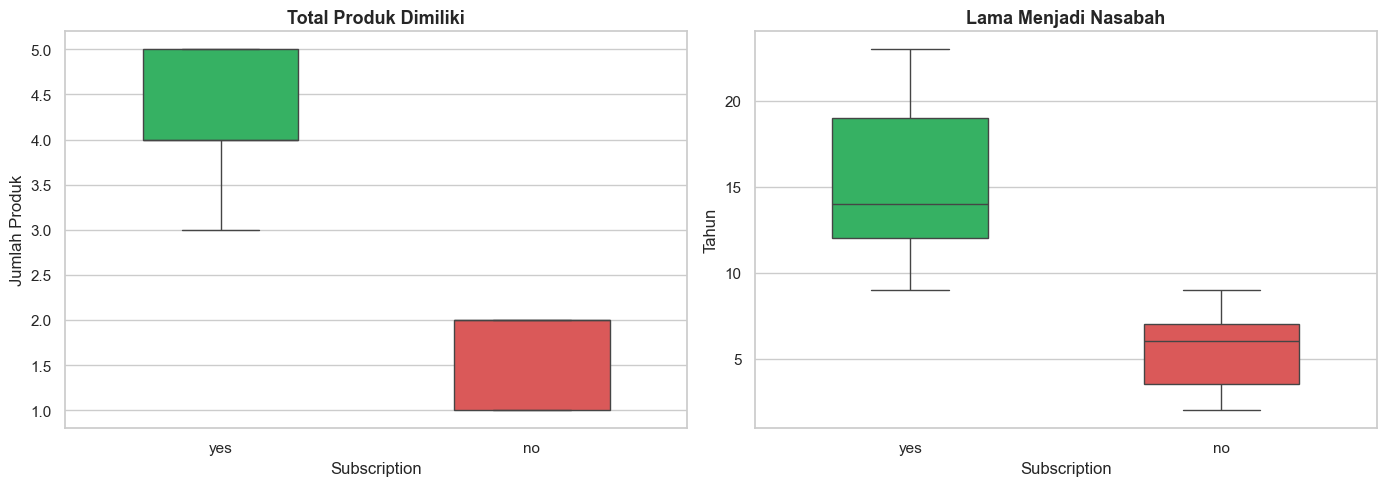


total_products_owned:
              mean  median  min  max
subscription                        
no             1.7     2.0    1    2
yes            4.2     4.0    3    5

years_as_customer:
              mean  median  min  max
subscription                        
no             5.3     6.0    2    9
yes           15.3    14.0    9   23


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Products owned
sns.boxplot(data=df, x='subscription', y='total_products_owned', ax=axes[0],
            palette={'yes': '#22c55e', 'no': '#ef4444'}, width=0.5)
axes[0].set_title('Total Produk Dimiliki')
axes[0].set_xlabel('Subscription')
axes[0].set_ylabel('Jumlah Produk')

# Years as customer
sns.boxplot(data=df, x='subscription', y='years_as_customer', ax=axes[1],
            palette={'yes': '#22c55e', 'no': '#ef4444'}, width=0.5)
axes[1].set_title('Lama Menjadi Nasabah')
axes[1].set_xlabel('Subscription')
axes[1].set_ylabel('Tahun')

plt.tight_layout()
plt.show()

for col in ['total_products_owned', 'years_as_customer']:
    print(f"\n{col}:")
    print(df.groupby('subscription')[col].agg(['mean', 'median', 'min', 'max']).round(1))

#### 2.2.3 Variabel Kategorikal vs Subscription

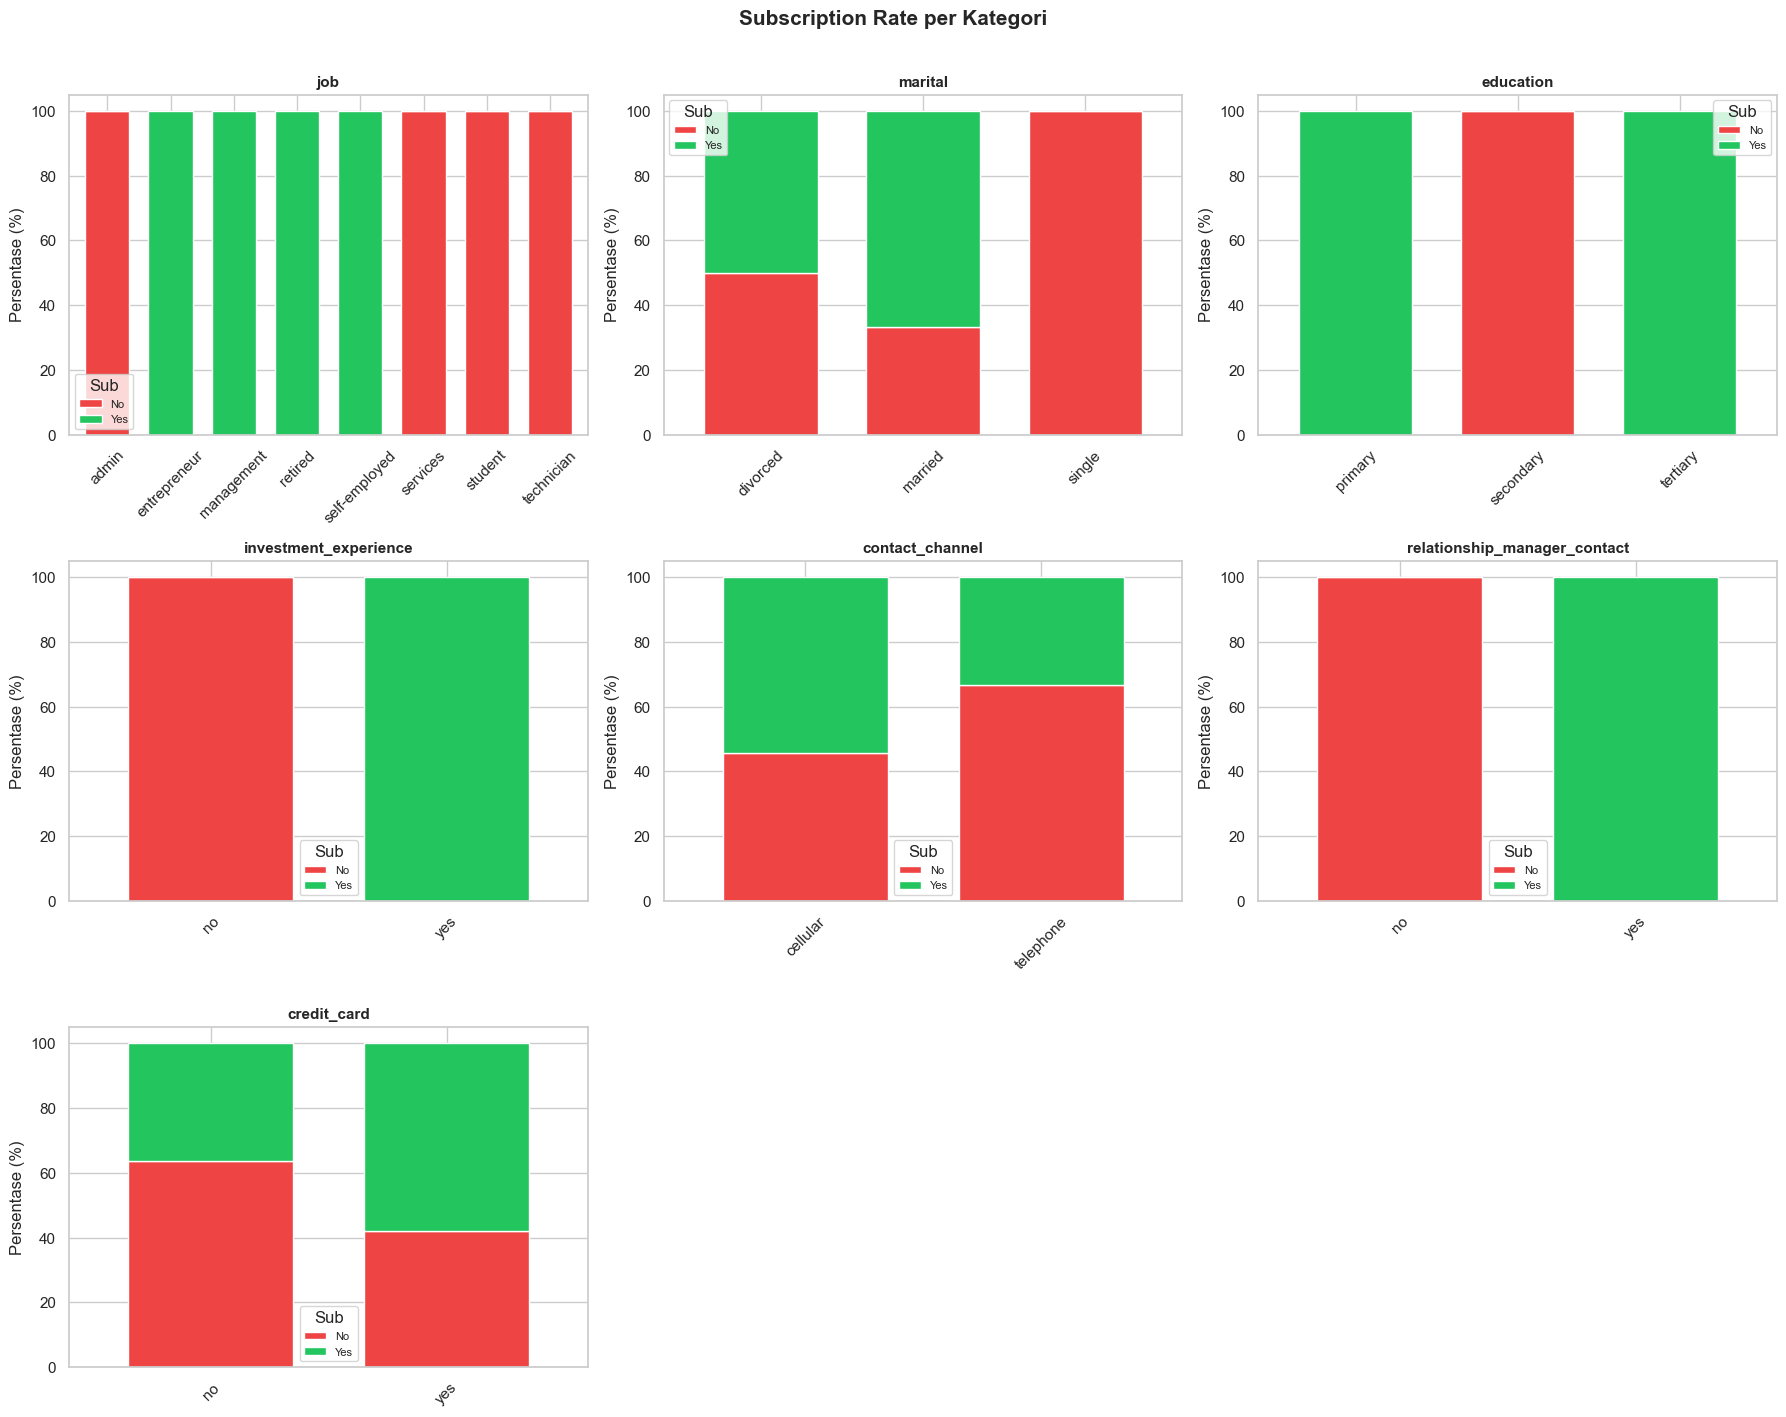

In [26]:
cat_vars = ['job', 'marital', 'education', 'investment_experience', 
            'contact_channel', 'relationship_manager_contact', 'credit_card']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, var in enumerate(cat_vars):
    ct = pd.crosstab(df[var], df['subscription'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i],
            color=['#ef4444', '#22c55e'], edgecolor='white', width=0.7)
    axes[i].set_title(f'{var}', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Persentase (%)')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(['No', 'Yes'], title='Sub', fontsize=8)
    axes[i].set_ylim(0, 105)

# Hide unused subplots
for j in range(len(cat_vars), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Subscription Rate per Kategori', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.3 Faktor Pembeda Sempurna (Perfect Predictors)

In [27]:
print("=" * 60)
print("VARIABEL DENGAN KORELASI SEMPURNA (100%) TERHADAP SUBSCRIPTION")
print("=" * 60)

for var in ['investment_experience', 'relationship_manager_contact']:
    ct = pd.crosstab(df[var], df['subscription'])
    pct = pd.crosstab(df[var], df['subscription'], normalize='index') * 100
    print(f"\n--- {var} ---")
    print(ct)
    print(f"\nSubscription Rate:")
    print(pct['yes'].apply(lambda x: f"{x:.0f}%"))

print("\n" + "=" * 60)
print("TEMUAN: Kedua variabel di atas memisahkan subscriber dan")
print("non-subscriber secara SEMPURNA (akurasi 100%).")
print("=" * 60)

VARIABEL DENGAN KORELASI SEMPURNA (100%) TERHADAP SUBSCRIPTION

--- investment_experience ---
subscription           no  yes
investment_experience         
no                     15    0
yes                     0   15

Subscription Rate:
investment_experience
no       0%
yes    100%
Name: yes, dtype: str

--- relationship_manager_contact ---
subscription                  no  yes
relationship_manager_contact         
no                            15    0
yes                            0   15

Subscription Rate:
relationship_manager_contact
no       0%
yes    100%
Name: yes, dtype: str

TEMUAN: Kedua variabel di atas memisahkan subscriber dan
non-subscriber secara SEMPURNA (akurasi 100%).


### 2.4 Korelasi antar Variabel Numerik

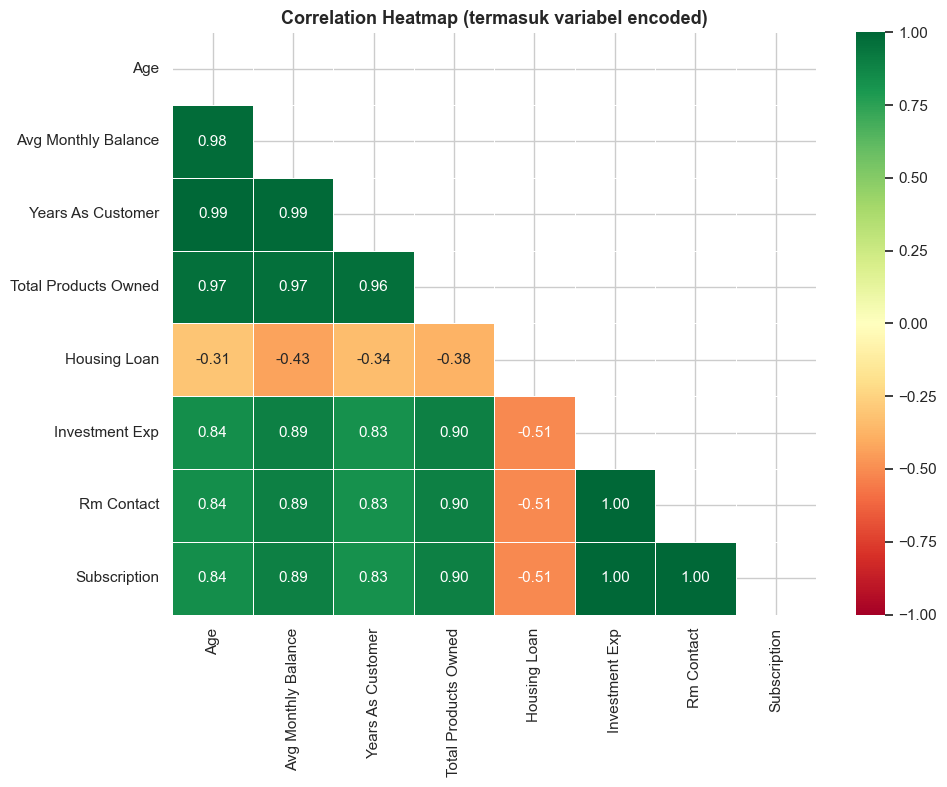

In [28]:
# Encode target untuk korelasi
df_corr = df.copy()
df_corr['subscription_encoded'] = (df_corr['subscription'] == 'yes').astype(int)
df_corr['housing_loan_encoded'] = (df_corr['housing_loan'] == 'yes').astype(int)
df_corr['investment_exp_encoded'] = (df_corr['investment_experience'] == 'yes').astype(int)
df_corr['rm_contact_encoded'] = (df_corr['relationship_manager_contact'] == 'yes').astype(int)

num_cols = ['age', 'avg_monthly_balance', 'years_as_customer', 'total_products_owned',
            'housing_loan_encoded', 'investment_exp_encoded', 'rm_contact_encoded', 
            'subscription_encoded']

corr_matrix = df_corr[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            xticklabels=[c.replace('_encoded','').replace('_',' ').title() for c in num_cols],
            yticklabels=[c.replace('_encoded','').replace('_',' ').title() for c in num_cols])
ax.set_title('Correlation Heatmap (termasuk variabel encoded)')
plt.tight_layout()
plt.show()

### 2.5 Ringkasan Perbandingan Subscriber vs Non-Subscriber

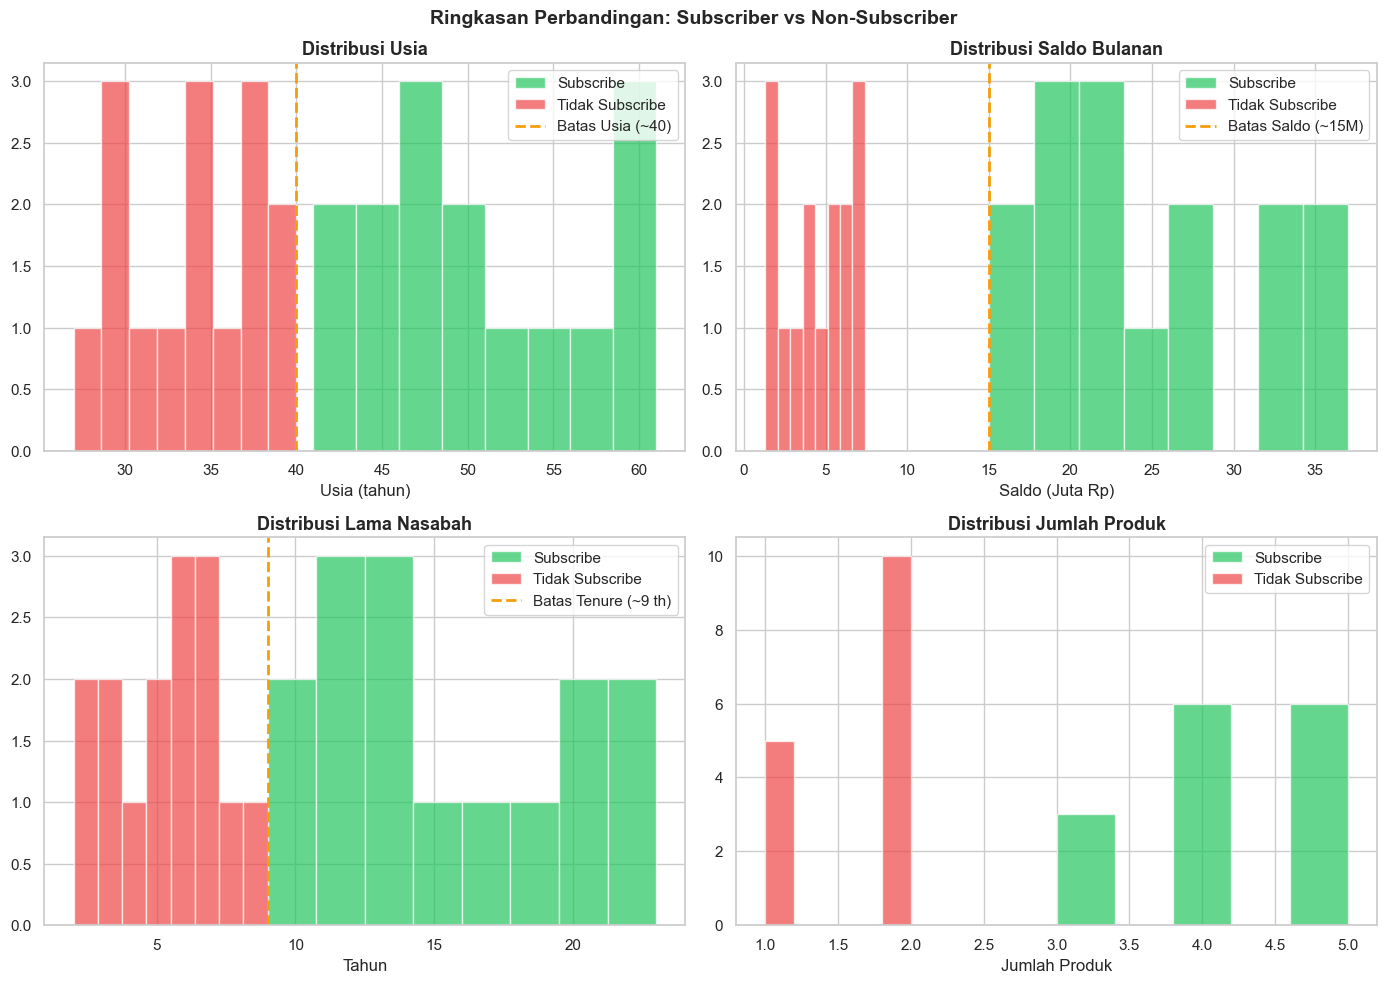

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Age distribution
axes[0, 0].hist(df[df['subscription']=='yes']['age'], bins=8, alpha=0.7, color='#22c55e', label='Subscribe', edgecolor='white')
axes[0, 0].hist(df[df['subscription']=='no']['age'], bins=8, alpha=0.7, color='#ef4444', label='Tidak Subscribe', edgecolor='white')
axes[0, 0].axvline(x=40, color='#f59e0b', linestyle='--', linewidth=2, label='Batas Usia (~40)')
axes[0, 0].set_title('Distribusi Usia')
axes[0, 0].set_xlabel('Usia (tahun)')
axes[0, 0].legend()

# 2. Balance distribution
axes[0, 1].hist(df[df['subscription']=='yes']['avg_monthly_balance']/1e6, bins=8, alpha=0.7, color='#22c55e', label='Subscribe', edgecolor='white')
axes[0, 1].hist(df[df['subscription']=='no']['avg_monthly_balance']/1e6, bins=8, alpha=0.7, color='#ef4444', label='Tidak Subscribe', edgecolor='white')
axes[0, 1].axvline(x=15, color='#f59e0b', linestyle='--', linewidth=2, label='Batas Saldo (~15M)')
axes[0, 1].set_title('Distribusi Saldo Bulanan')
axes[0, 1].set_xlabel('Saldo (Juta Rp)')
axes[0, 1].legend()

# 3. Years as customer
axes[1, 0].hist(df[df['subscription']=='yes']['years_as_customer'], bins=8, alpha=0.7, color='#22c55e', label='Subscribe', edgecolor='white')
axes[1, 0].hist(df[df['subscription']=='no']['years_as_customer'], bins=8, alpha=0.7, color='#ef4444', label='Tidak Subscribe', edgecolor='white')
axes[1, 0].axvline(x=9, color='#f59e0b', linestyle='--', linewidth=2, label='Batas Tenure (~9 th)')
axes[1, 0].set_title('Distribusi Lama Nasabah')
axes[1, 0].set_xlabel('Tahun')
axes[1, 0].legend()

# 4. Products owned
axes[1, 1].hist(df[df['subscription']=='yes']['total_products_owned'], bins=5, alpha=0.7, color='#22c55e', label='Subscribe', edgecolor='white')
axes[1, 1].hist(df[df['subscription']=='no']['total_products_owned'], bins=5, alpha=0.7, color='#ef4444', label='Tidak Subscribe', edgecolor='white')
axes[1, 1].set_title('Distribusi Jumlah Produk')
axes[1, 1].set_xlabel('Jumlah Produk')
axes[1, 1].legend()

plt.suptitle('Ringkasan Perbandingan: Subscriber vs Non-Subscriber', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Kesimpulan

### 3.1 Temuan Utama

| Variabel | Subscriber (Yes) | Non-Subscriber (No) | Keterangan |
|----------|:-----------------:|:--------------------:|------------|
| **Usia** | Rata-rata 50.5 th (min 41) | Rata-rata 33.9 th (max 40) | Tidak ada overlap, batas ~40 tahun |
| **Saldo Bulanan** | Rata-rata Rp 24.5M (min 15M) | Rata-rata Rp 4.6M (max 7.4M) | Subscriber punya saldo 5.3× lebih tinggi |
| **Lama Nasabah** | Rata-rata 15.3 tahun | Rata-rata 5.3 tahun | Subscriber 3× lebih lama |
| **Jumlah Produk** | Rata-rata 4.2 produk | Rata-rata 1.7 produk | Engagement jauh lebih tinggi |
| **Housing Loan** | 93% tanpa housing loan | 53% tanpa housing loan | Housing loan = barrier |
| **Investment Exp.** | 100% punya pengalaman | 0% punya pengalaman | **Perfect predictor** |
| **RM Contact** | 100% dihubungi RM | 0% dihubungi RM | **Perfect predictor** |

### 3.2 Profil Nasabah Paling Potensial untuk Ditargetkan RM

> **Nasabah ideal untuk produk deposito jangka panjang:**
> - Usia ≥ 41 tahun
> - Saldo bulanan rata-rata ≥ Rp 15 juta
> - Lama menjadi nasabah ≥ 9 tahun
> - Tidak memiliki housing loan aktif
> - Memiliki ≥ 3 produk bank
> - Pekerjaan: management, retired, self-employed, atau entrepreneur
> - Pendidikan: tertiary atau primary (senior)

### 3.3 Rekomendasi Aksi untuk Relationship Manager

1. **Prioritaskan kontak personal** — `relationship_manager_contact` berkorelasi sempurna (100%) dengan subscription. Semua nasabah yang dihubungi RM akhirnya subscribe.

2. **Edukasi investasi sebagai "jembatan"** — `investment_experience` juga berkorelasi 100%. Program literasi keuangan bisa menjadi langkah awal sebelum menawarkan deposito.

3. **Segmentasi berdasarkan saldo & usia** — Fokuskan effort pada nasabah usia ≥40 tahun dengan saldo ≥Rp 15M. Ini adalah kelompok dengan potensi konversi tertinggi.

4. **Hindari nasabah dengan housing loan aktif** — Subscription rate hanya 11.1%. Beban cicilan mengurangi minat dan kapasitas untuk investasi jangka panjang.